In [10]:
from netCDF4 import Dataset as NETCDF4Dataset
from utils.config import PROJECT_ROOT
from pathlib import Path

filepath = Path(PROJECT_ROOT) / "data/argo/Argo_mixedlayers_all_04142022.nc"
dataset = NETCDF4Dataset(filepath)

In [11]:
dataset

<class 'netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    description: This file was created using 
 matlab R2019b with NETCDF Library Functions

    date: 17-Jun-2022
    dimensions(sizes): iNPROF(2480040), iTXT(110)
    variables(dimensions): float64 da_mld(iNPROF), float64 da_mlpd(iNPROF), float64 da_mls(iNPROF), float64 da_mlt(iNPROF), float64 dt_mld(iNPROF), float64 dt_mlpd(iNPROF), float64 dt_mls(iNPROF), float64 dt_mlt(iNPROF), float64 floatnumber(iNPROF), float64 profiledate(iNPROF), float64 profilelat(iNPROF), float64 profilelon(iNPROF), float64 profilenumber(iNPROF), float64 status(iNPROF), float64 ta_mld(iNPROF), float64 tt_mld(iNPROF)
    groups: 

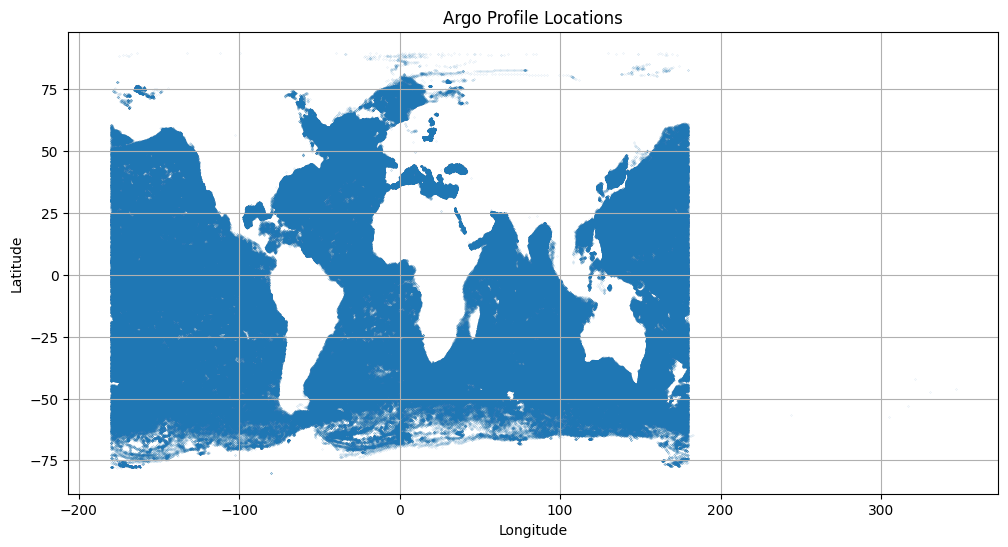

In [12]:
import matplotlib.pyplot as plt

# Extract latitude and longitude from the dataset
lats = dataset.variables['profilelat'][:]
lons = dataset.variables['profilelon'][:]

plt.figure(figsize=(12, 6))
plt.scatter(lons, lats, s=0.01, alpha=0.5)
plt.title("Argo Profile Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

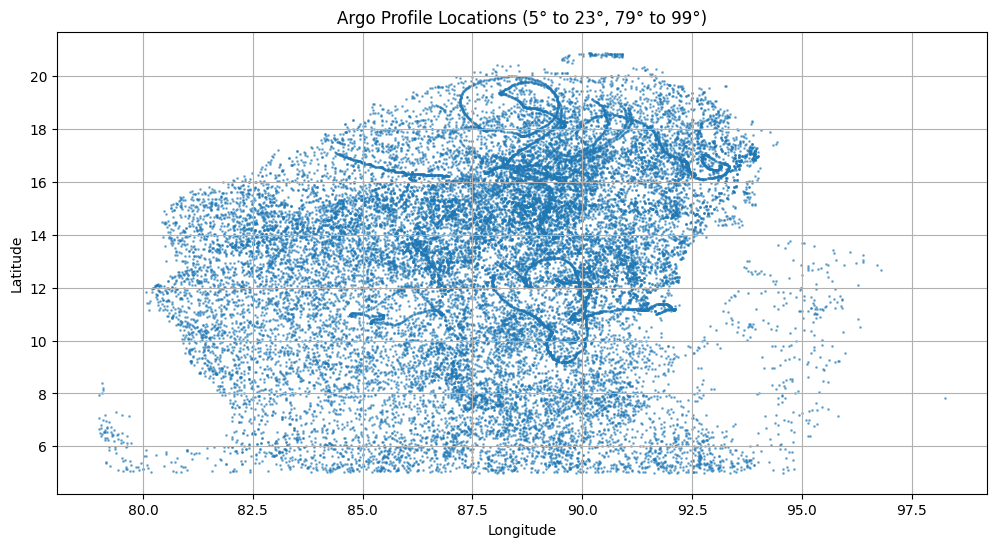

In [29]:
lat_min, lat_max = 5, 23
lon_min, lon_max = 79, 99

mask = (lats >= lat_min) & (lats <= lat_max) & (lons >= lon_min) & (lons <= lon_max)

plt.figure(figsize=(12, 6))
plt.scatter(lons[mask], lats[mask], s=1, alpha=0.5)
plt.title(f"Argo Profile Locations ({lat_min}° to {lat_max}°, {lon_min}° to {lon_max}°)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

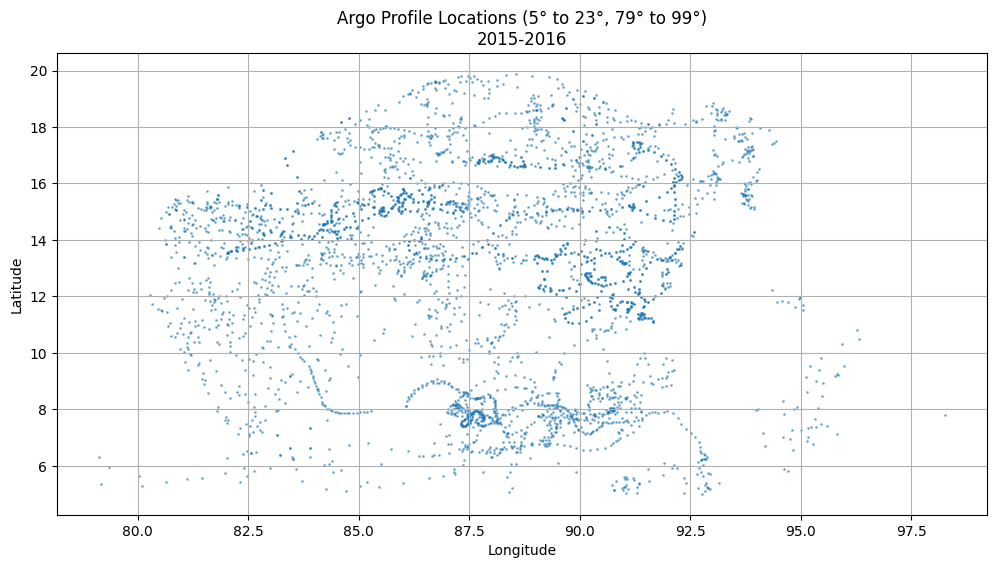

In [35]:
import numpy as np
from datetime import datetime, timedelta

# Let's filter profiles within a specific time range.
# For example, select profiles from 2015 to 2016.

# Extract profile dates (assuming they are in MATLAB datenum format)
profile_dates = dataset.variables['profiledate'][:]

# Convert MATLAB datenum to Python datetime

def matlab_datenum_to_datetime(matlab_datenum):
    # MATLAB datenum is days since 0000-01-01, Python datetime is from 0001-01-01
    # MATLAB's day 1 is 0000-01-01, Python's is 0001-01-01, so subtract 366 days
    return datetime.fromordinal(int(matlab_datenum)) + timedelta(days=matlab_datenum%1) - timedelta(days=366)

# Define time range
start_year, end_year = 2015, 2016
start_date = datetime(start_year, 1, 1)
end_date = datetime(end_year, 12, 31)
# end_date = datetime(start_year, 1, 31)

# Convert all profile dates to datetime
profile_datetimes = np.array([matlab_datenum_to_datetime(d) for d in profile_dates])

# Create a time mask
time_mask = (profile_datetimes >= start_date) & (profile_datetimes <= end_date)

# Combine with spatial mask
combined_mask = mask & time_mask

plt.figure(figsize=(12, 6))
plt.scatter(lons[combined_mask], lats[combined_mask], s=1, alpha=0.5)
plt.title(f"Argo Profile Locations ({lat_min}° to {lat_max}°, {lon_min}° to {lon_max}°)\n{start_year}-{end_year}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

    torch (>=2.7.0+cu118,<3.0.0)
           ~~~~~~~^
Note: you may need to restart the kernel to use updated packages.


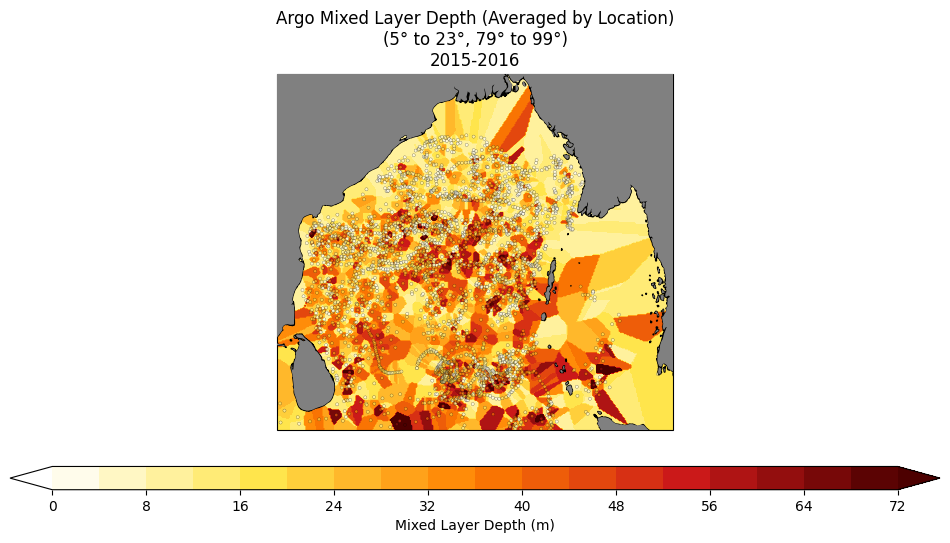

In [ ]:
%pip install cartopy cmocean matplotlib

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import cmocean
import matplotlib as mpl

# Use the already loaded mld, lats, lons, combined_mask, etc.

# Group by unique (lon, lat) and take the mean MLD for each location
# (df, grouped, avg_lons, avg_lats, avg_mld, argo_points, tree, grid_points, grid_mld, lon_mesh, lat_mesh, etc. are already defined)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Custom colormap: 0 is white, mid is yellow/orange, high is dark red/brown
from matplotlib.colors import LinearSegmentedColormap

# Define a custom colormap
colors = [
	(1.0, 1.0, 1.0),      # white for 0
	(1.0, 0.9, 0.3),      # yellowish
	(1.0, 0.5, 0.0),      # orange
	(0.8, 0.1, 0.1),      # red
	(0.3, 0.0, 0.0)       # dark
]
cmap = LinearSegmentedColormap.from_list("custom_mld", colors, N=256)

levels = np.arange(0, 73, 4)  # 0 to 72 by 4, matching the image colorbar
cf = ax.contourf(
	lon_mesh, lat_mesh, grid_mld, 
	levels=levels, 
	cmap=cmap, 
	extend='both', 
	transform=ccrs.PlateCarree()
)
sc = ax.scatter(avg_lons, avg_lats, c=avg_mld, cmap=cmap, s=5, alpha=0.7, edgecolor='k', linewidth=0.2, transform=ccrs.PlateCarree())

# Add land and coastlines
ax.add_feature(cfeature.LAND, zorder=100, facecolor='gray')
ax.coastlines(resolution='10m', color='black', linewidth=1)

plt.title(f"Argo Mixed Layer Depth (Averaged by Location)\n({lat_min}° to {lat_max}°, {lon_min}° to {lon_max}°)\n{start_year}-{end_year}")

# Place colorbar below the plot
cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.08, aspect=40, label="Mixed Layer Depth (m)")









plt.show()

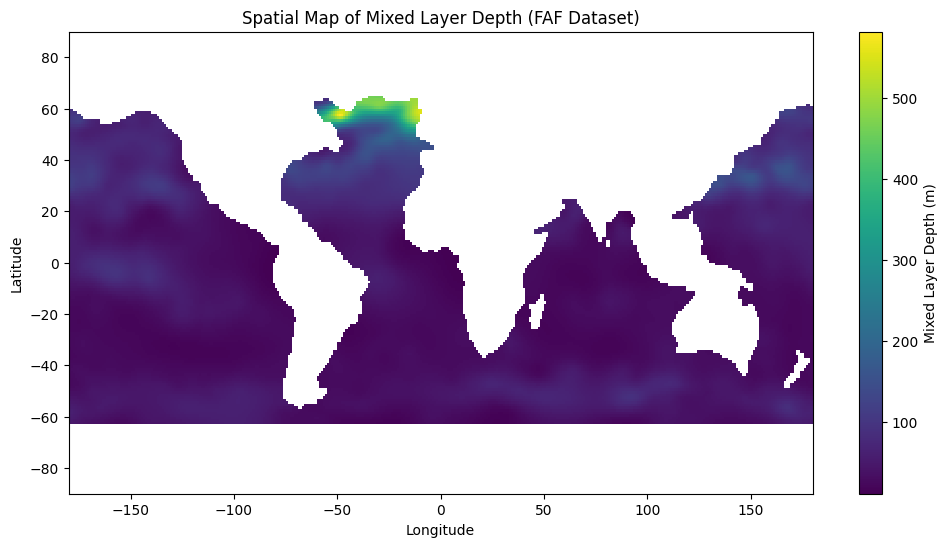

In [44]:
# Extract longitude, latitude, and MLD from the dataset
lons_faf = faf_dataset.variables['LONN179_180'][:]
lats_faf = faf_dataset.variables['LAT'][:]
mld_faf = faf_dataset.variables['MLD'][0, :, :]  # Use the first (and only) time slice

plt.figure(figsize=(12, 6))
plt.pcolormesh(lons_faf, lats_faf, mld_faf, shading='auto', cmap='viridis')
plt.colorbar(label='Mixed Layer Depth (m)')
plt.title('Spatial Map of Mixed Layer Depth (FAF Dataset)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

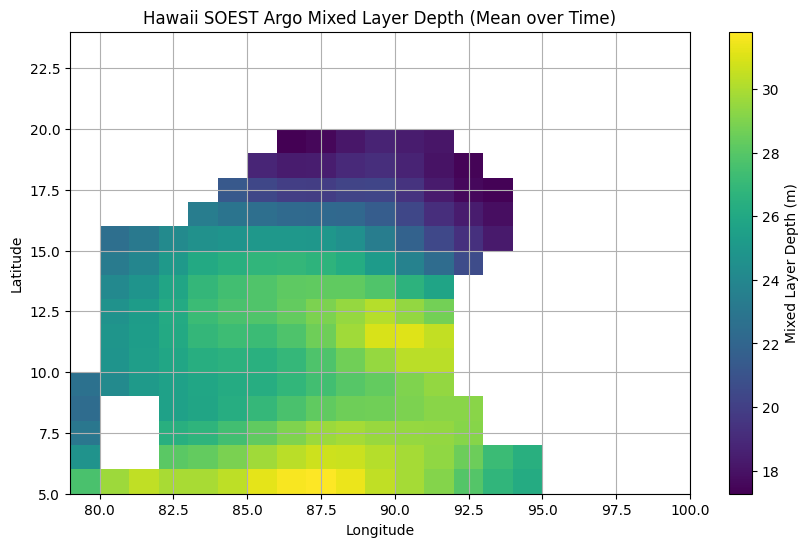

In [50]:
from netCDF4 import Dataset
import numpy as np

import matplotlib.pyplot as plt

# Load the dataset (replace with your actual file path if needed)
hawaii_path = Path(PROJECT_ROOT) / "data/argo/hawaii_soest_b43f_3192_f51e_4b7b_649e_7800.nc"
hawaii_dataset = Dataset(hawaii_path)

# Extract variables
hawaii_lats = hawaii_dataset.variables['latitude'][:]
hawaii_lons = hawaii_dataset.variables['longitude'][:]
hawaii_mld = hawaii_dataset.variables['mld'][:]  # shape: (time, lat, lon)

# Compute mean over time, ignoring masked values
hawaii_mld_mean = np.ma.mean(hawaii_mld, axis=0)

# Create meshgrid for plotting
lon_grid, lat_grid = np.meshgrid(hawaii_lons, hawaii_lats)

plt.figure(figsize=(10, 6))
pcm = plt.pcolormesh(lon_grid, lat_grid, hawaii_mld_mean, cmap='viridis', shading='auto')
plt.colorbar(pcm, label='Mixed Layer Depth (m)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Hawaii SOEST Argo Mixed Layer Depth (Mean over Time)')
plt.grid(True)
plt.show()

In [72]:
# Load the dataset
clim_path = Path(PROJECT_ROOT) / "data/argo/Argo_mixedlayers_all_04142022.nc"
clim_dataset = Dataset(clim_path)
clim_dataset

<class 'netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    description: This file was created using 
 matlab R2019b with NETCDF Library Functions

    date: 17-Jun-2022
    dimensions(sizes): iNPROF(2480040), iTXT(110)
    variables(dimensions): float64 da_mld(iNPROF), float64 da_mlpd(iNPROF), float64 da_mls(iNPROF), float64 da_mlt(iNPROF), float64 dt_mld(iNPROF), float64 dt_mlpd(iNPROF), float64 dt_mls(iNPROF), float64 dt_mlt(iNPROF), float64 floatnumber(iNPROF), float64 profiledate(iNPROF), float64 profilelat(iNPROF), float64 profilelon(iNPROF), float64 profilenumber(iNPROF), float64 status(iNPROF), float64 ta_mld(iNPROF), float64 tt_mld(iNPROF)
    groups: 

In [75]:
clim_dataset.variables.keys()
mld = clim_dataset.variables['dt_mld']
lon = clim_dataset.variables['profilelon']
lat = clim_dataset.variables['profilelat']
mld.shape, lon.shape, lat.shape

((2480040,), (2480040,), (2480040,))

masked_array(data=38.47469047,
             mask=False,
       fill_value=1e+20)

In [76]:
# Plot the spatial distribution of mean MLD from clim_dataset

# Compute the mean MLD over time (axis=0), ignoring masked values
mld_clim_mean = np.ma.mean(mld, axis=0)

plt.figure(figsize=(12, 6))
pcm = plt.pcolormesh(lon, lat, mld_clim_mean, cmap='viridis', shading='auto')
plt.colorbar(pcm, label='Mixed Layer Depth (m)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Spatial Map of Mean Mixed Layer Depth (clim_dataset)')
plt.show()

RecursionError: maximum recursion depth exceeded

(180, 360, 12)
(180, 360)


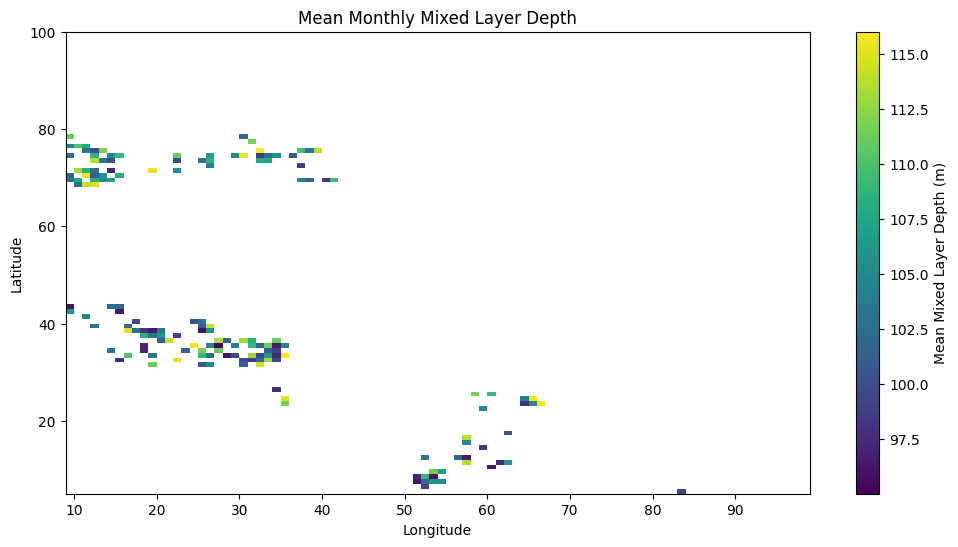

In [ ]:
clim_path = Path(PROJECT_ROOT) / "data/argo/Argo_mixedlayers_monthlyclim_04142022.nc"
clim_dataset = Dataset(clim_path)

# Extract variables
mld_monthly = clim_dataset["mld_dt_mean"][:]
lats_clim = clim_dataset["lat"][:]
lons_clim = clim_dataset["lon"][:]

# mld_monthly shape: (12, lat, lon)
# Compute mean over months (axis=0)
mld_average = np.mean(mld_monthly, axis=2)
mld_average[mld_average < 0] = np.nan

print(mld_monthly.shape)
print(mld_monthly[...,0].shape)
lat_min, lat_max = 5, 87.5
lon_min, lon_max = 9, 99
plt.figure(figsize=(12, 6))
# Plot with correct lat/lon axes
# plt.pcolormesh(lons_clim, lats_clim, mld_average, cmap='viridis', shading='auto')
plt.pcolormesh(lons_clim, lats_clim, mld_average, cmap='viridis', shading='auto')
plt.colorbar(label='Mean Mixed Layer Depth (m)')
plt.title('Mean Monthly Mixed Layer Depth')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()
plt.show()



In [ ]:
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()

masked_array(data=[-179.5, -178.5, -177.5, -176.5, -175.5, -174.5, -173.5,
                   -172.5, -171.5, -170.5, -169.5, -168.5, -167.5, -166.5,
                   -165.5, -164.5, -163.5, -162.5, -161.5, -160.5, -159.5,
                   -158.5, -157.5, -156.5, -155.5, -154.5, -153.5, -152.5,
                   -151.5, -150.5, -149.5, -148.5, -147.5, -146.5, -145.5,
                   -144.5, -143.5, -142.5, -141.5, -140.5, -139.5, -138.5,
                   -137.5, -136.5, -135.5, -134.5, -133.5, -132.5, -131.5,
                   -130.5, -129.5, -128.5, -127.5, -126.5, -125.5, -124.5,
                   -123.5, -122.5, -121.5, -120.5, -119.5, -118.5, -117.5,
                   -116.5, -115.5, -114.5, -113.5, -112.5, -111.5, -110.5,
                   -109.5, -108.5, -107.5, -106.5, -105.5, -104.5, -103.5,
                   -102.5, -101.5, -100.5,  -99.5,  -98.5,  -97.5,  -96.5,
                    -95.5,  -94.5,  -93.5,  -92.5,  -91.5,  -90.5,  -89.5,
                    -88.5

In [123]:
datapath = Path(PROJECT_ROOT) / "data/argo/107685.nc"
dataset = NETCDF4Dataset(datapath)
dataset


<class 'netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    title: Monthly climatology of the oceanic Mixed Layer Depth (MLD) (mld_dr003_ref05m.nc, v2024)
    institution: LOPS laboratory (IFREMER, Univ. of Brest, CNRS, IRD), Brest, France
    source: This MLD climatology is generated by monthly mapping (OI/kriging) of MLD estimations from individual ocean casts/profiles measuring pressure/depth, temperature and salinity, and coming from the ARGO program (argo.ucsd.edu ; argo.net), and from the NOAA NCEI World Ocean Database (www.ncei.noaa.gov/products/world-ocean-database): CTD, APB (sea mammals), OSD (bottles), MRB (moored buoys including e.g. TAO array), GLD (gliders), UOR (undulating ocean recorder, e.g. seasor), DRB (drifting buoys, including e.g. Ice Tethered Profilers). Original L3 file timestamp: Fri Jul 14 11:47:30 2023
    references: DOI of this dataset: https://doi.org/10.17882/98226 (de Boyer Montégut 2024, SEANOE dataset publication, https:

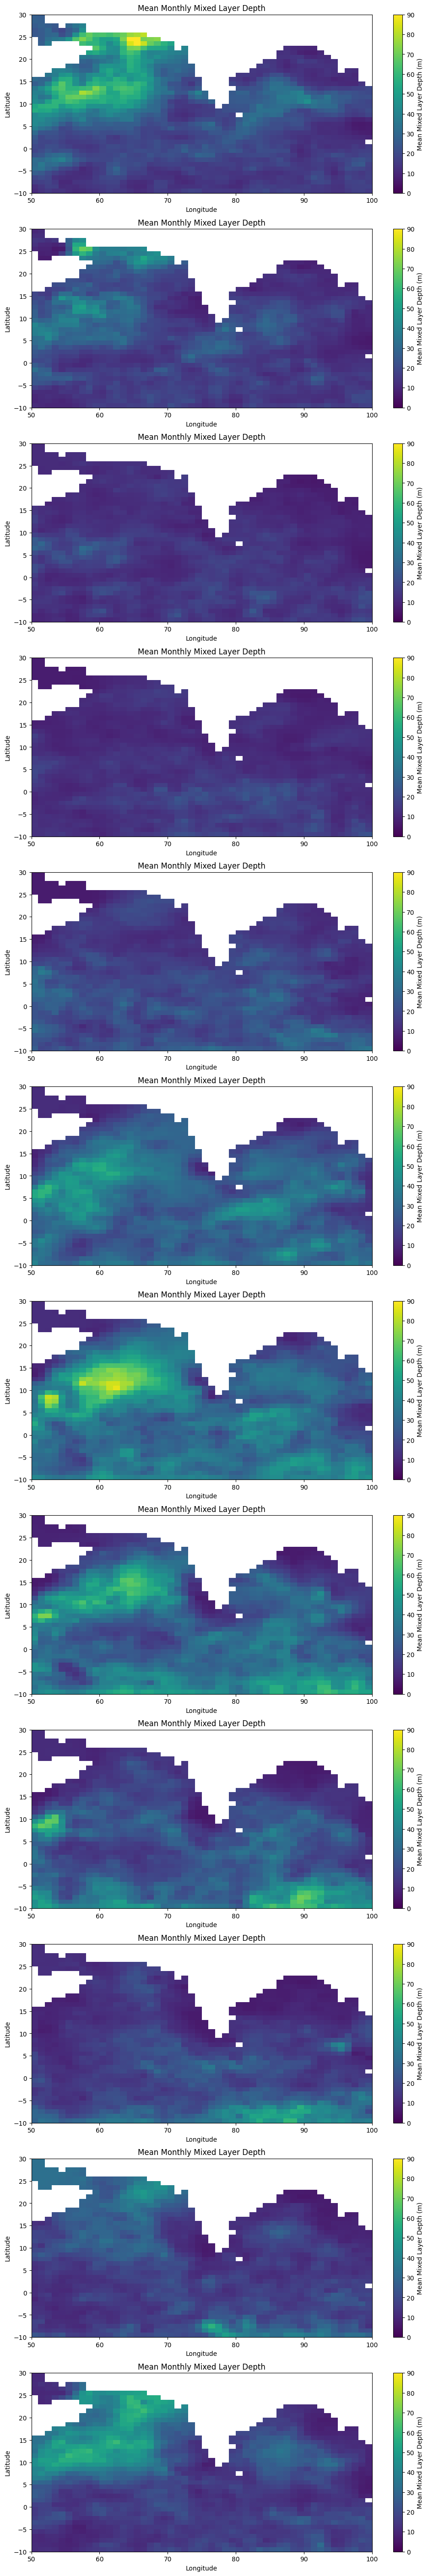

In [141]:
onemonth_mld = dataset["mld_dr003"][0]
lat = dataset["lat"]
lon = dataset["lon"]

lat_min, lat_max = -10, 30
lon_min, lon_max = 50, 100
fig, ax = plt.subplots(figsize=(12, 6*12), nrows=12, ncols=1)
for i in range(12):
    ds = dataset["mld_dr003"][i]
    ax[i].pcolormesh(lon, lat, ds, cmap='viridis', shading='auto', vmin=0, vmax=90)
    fig.colorbar(label='Mean Mixed Layer Depth (m)', ax=ax[i], mappable=ax[i].collections[0])
    ax[i].set_title('Mean Monthly Mixed Layer Depth')
    ax[i].set_xlabel('Longitude')
    ax[i].set_ylabel('Latitude')
    ax[i].set_xlim(lon_min, lon_max)
    ax[i].set_ylim(lat_min, lat_max)
plt.show()